# Comparativa de ASR usando BERTScore

Este notebook calcula el BERTScore entre las transcripciones normalizadas (`text_normalized`) y las oraciones de referencia (ground truth).

Se utiliza una versión ligera del modelo para una ejecución rápida, pero se deja comentada la opción de usar un modelo más pesado (transformers grandes) para obtener métricas potencialmente más precisas.

## 1. Cargar Datos

In [1]:
import pandas as pd
# Cargar el dataset normalizado
df = pd.read_csv('dataset_bert.csv')
# Verificar las primeras filas
df.head(3)

,person,audio,noise,snr,provider,text,status,transcription_time,text_normalized,bertscore_precision,bertscore_recall,bertscore_f1
0,p7,1,cafe,0dB,whisper,Genera una cotización para el cliente con fáci...,success,1.65,genera una cotización para el cliente con fáci...,0.767834,0.697496,0.732945
1,p7,1,cafe,5dB,whisper,Genera una cotización para el cliente con PUC ...,success,1.56,genera una cotización para el cliente con puc ...,0.679186,0.695428,0.687867
2,p7,1,cafe,10dB,whisper,Genera una cotización para el cliente con Puff...,success,1.59,genera una cotización para el cliente con puff...,0.452849,0.686818,0.568367


In [2]:
# Mostrar estadísticas descriptivas de los scores
print("Estadísticas de BERTScore F1:")
print(df['bertscore_f1'].describe())

# Mostrar promedio agrupado por proveedor (provider)
if 'provider' in df.columns:
    print("\nPromedio de BERTScore F1 por proveedor:")
    print(df.groupby('provider')['bertscore_f1'].mean().sort_values(ascending=False))

# Mostrar promedio agrupado por nivel de ruido (noise)
if 'noise' in df.columns:
    print("\nPromedio de BERTScore F1 por tipo de ruido:")
    print(df.groupby('noise')['bertscore_f1'].mean().sort_values(ascending=False))

# Mostrar promedio agrupado por nivel de ruido (noise)
if 'snr' in df.columns:
    print("\nPromedio de BERTScore F1 por nivel de ruido:")
    print(df.groupby('snr')['bertscore_f1'].mean().sort_values(ascending=False))

Estadísticas de BERTScore F1:
count    6000.000000
mean        0.880643
std         0.188944
min        -0.375530
25%         0.797588
50%         0.999999
75%         1.000000
max         1.000001
Name: bertscore_f1, dtype: float64

Promedio de BERTScore F1 por proveedor:
provider
google     0.918881
whisper    0.887266
amazon     0.864899
azure      0.851524
Name: bertscore_f1, dtype: float64

Promedio de BERTScore F1 por tipo de ruido:
noise
clean        0.948609
cafe         0.890868
traffic      0.885571
warehouse    0.842833
Name: bertscore_f1, dtype: float64

Promedio de BERTScore F1 por nivel de ruido:
snr
clean    0.948609
10dB     0.930338
5dB      0.904201
0dB      0.784733
Name: bertscore_f1, dtype: float64


## 2. BertScore por ASR con intervalos de confianza (95%)

Gráfico de barras con la media de BERTScore F1 por proveedor (ASR) e intervalos de confianza al 95% calculados por bootstrap (igual que en CER y WER).

BERTScore F1 por ASR con intervalo de confianza (95%)


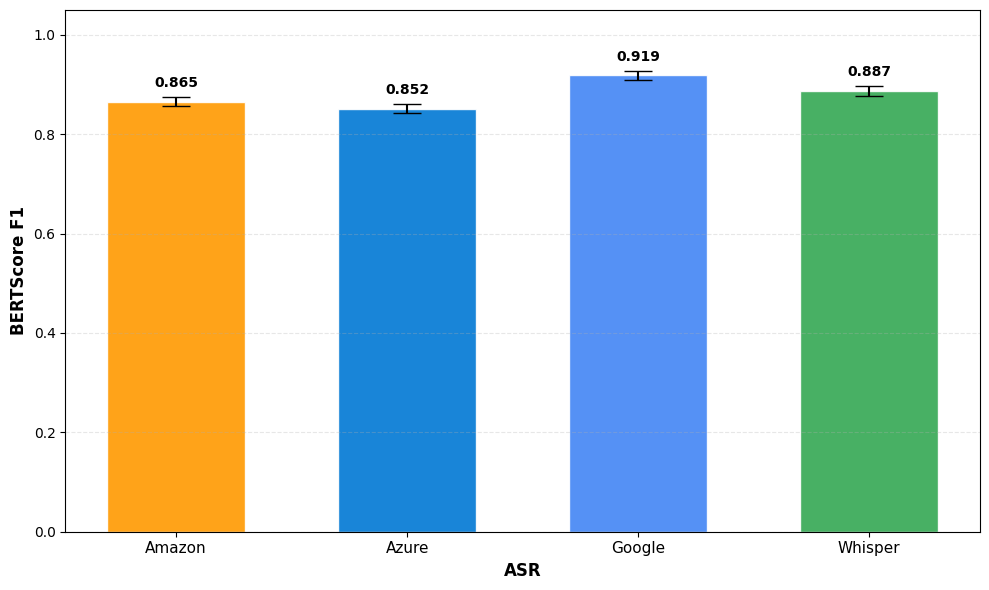

Tabla: BERTScore F1 por ASR con intervalos de confianza (95%)


ASR,BERTScore F1,IC 95% Inf,IC 95% Sup
Amazon,0.8649,0.8563,0.8741
Azure,0.8515,0.8418,0.8612
Google,0.9189,0.9099,0.9273
Whisper,0.8873,0.8777,0.8964



Análisis Estadístico de Significancia (BERTScore F1)
N (muestras/bloques) = 1500
Test de Friedman: Estadístico=358.6821, p-value=1.9664e-77, W de Kendall=0.0797
>> Diferencias significativas encontradas. Realizando post-hoc (Wilcoxon + Holm-Bonferroni)...


Comparación,Estadístico W,p-value original,p-value adj (Holm-Bonferroni),Significativo,Tamaño del Efecto (r)
amazon vs azure,185674,1.1769e-03,1.1769e-03,True,0.5804
amazon vs google,73864,1.6413e-37,8.2067e-37,True,0.7525
amazon vs whisper,121662,4.2931e-10,8.5862e-10,True,0.6790
azure vs google,58616,1.2946e-51,7.7675e-51,True,0.7760
azure vs whisper,94286,1.3334e-22,5.3336e-22,True,0.7211
google vs whisper,60464,2.0217e-16,6.0651e-16,True,0.7731


In [3]:
from tools.bertscore_analysis import BERTScoreAnalyzer, BERTScoreVisualizer

# Inicializar analizador
analyzer = BERTScoreAnalyzer(df)

# Calcular estadísticas
stats_df = analyzer.calculate_stats_by_provider()

# Visualizar gráfico
BERTScoreVisualizer.plot_bertscore_by_provider(stats_df)

# Mostrar tabla resumen
BERTScoreVisualizer.display_summary_table(stats_df)

# Realizar pruebas estadísticas
friedman_result, wilcoxon_df = analyzer.perform_statistical_tests()

# Mostrar resultados estadísticos
BERTScoreVisualizer.display_statistical_results(friedman_result, wilcoxon_df)

## 3. Distribución y estadísticas descriptivas por ASR

Diagrama de cajas (boxplot) de BERTScore F1 y tabla de estadísticas descriptivas por proveedor.

Distribución de BERTScore F1 por ASR


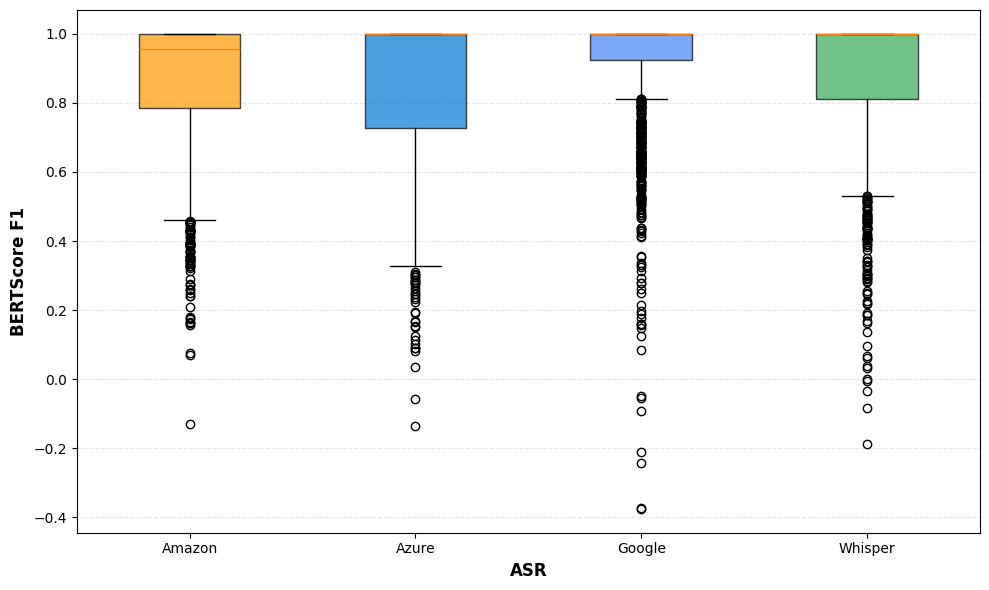


Estadísticas Descriptivas de BERTScore F1 por ASR


ASR,Media,Mediana,Mínimo,Máximo,Desv. Est.,Q1,Q3,IQR,Muestras
Amazon,0.8649,0.9564,-0.1296,1.0000,0.1881,0.7837,1.0000,0.2163,1500
Azure,0.8515,1.0000,-0.1363,1.0000,0.1975,0.7276,1.0000,0.2724,1500
Google,0.9189,1.0000,-0.3755,1.0000,0.1706,0.9244,1.0000,0.0756,1500
Whisper,0.8873,1.0000,-0.1875,1.0000,0.1917,0.8125,1.0000,0.1875,1500


In [4]:
from tools.bertscore_analysis import BERTScoreVisualizer

# Diagrama de cajas
BERTScoreVisualizer.plot_bertscore_boxplot(df)

# Tabla de estadísticas descriptivas por ASR
BERTScoreVisualizer.display_detailed_statistics(df)

## 4. BERTScore por Nivel de Ruido y ASR

Gráfico de líneas de BERTScore F1 por nivel de ruido (SNR) y proveedor.

BERTScore F1 por Nivel de Ruido y ASR


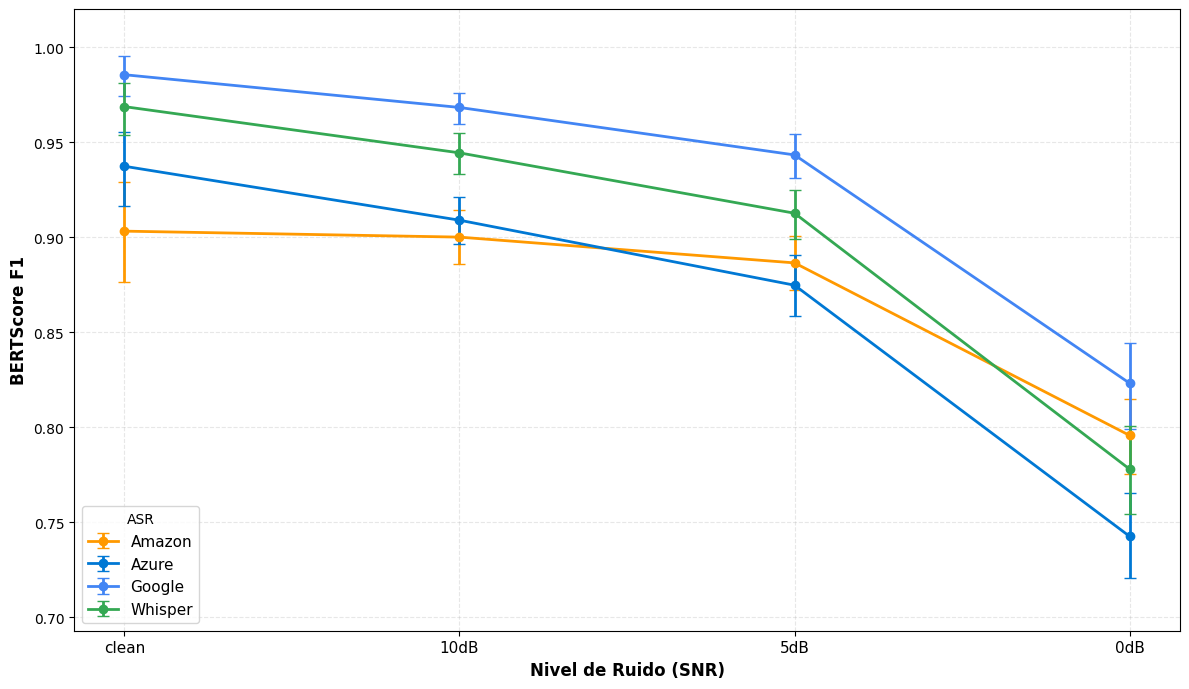


Tabla: BERTScore F1 por Nivel de Ruido y ASR


ASR,Base,10 dB,5 dB,0 dB,Degradación
Amazon,"0.9031 [0.8762, 0.9290]","0.9000 [0.8859, 0.9145]","0.8864 [0.8720, 0.9007]","0.7956 [0.7754, 0.8146]",0.1075
Azure,"0.9373 [0.9161, 0.9554]","0.9089 [0.8962, 0.9213]","0.8747 [0.8584, 0.8905]","0.7425 [0.7203, 0.7655]",0.1948
Google,"0.9854 [0.9740, 0.9952]","0.9682 [0.9597, 0.9760]","0.9432 [0.9312, 0.9544]","0.8230 [0.7991, 0.8442]",0.1624
Whisper,"0.9686 [0.9537, 0.9811]","0.9443 [0.9331, 0.9546]","0.9125 [0.8989, 0.9248]","0.7778 [0.7543, 0.8007]",0.1908


Análisis estadístico para escenario 0dB:

Análisis Estadístico (0dB)
N (muestras/bloques) = 450
Test de Friedman: Estadístico=87.6496, p-value=7.0035e-19, W de Kendall=0.0649
>> Diferencias significativas encontradas. Realizando post-hoc (Wilcoxon + Holm-Bonferroni)...


Comparación,Estadístico W,p-value original,p-value adj (Holm-Bonferroni),Significativo,Tamaño del Efecto (r)
amazon vs azure,20106,1.0253e-07,5.1267e-07,True,0.5231
amazon vs google,19459,1.7274e-04,3.4548e-04,True,0.5342
amazon vs whisper,23693,1.6734e-01,1.6734e-01,False,0.4619
azure vs google,14819,5.7091e-15,3.4255e-14,True,0.6134
azure vs whisper,20580,5.1076e-06,1.5323e-05,True,0.5150
google vs whisper,16178,1.6418e-06,6.5672e-06,True,0.5902


In [5]:
# Calcular estadísticas por SNR y proveedor
stats_snr = analyzer.calculate_stats_by_provider_and_snr()

# Visualizar gráfico por SNR
BERTScoreVisualizer.plot_bertscore_by_snr(stats_snr)

# Mostrar tabla resumen por SNR
BERTScoreVisualizer.display_summary_table_by_snr(stats_snr)

# Análisis estadístico para SNR = 0dB
print("Análisis estadístico para escenario 0dB:")
friedman_0db, wilcoxon_0db = analyzer.perform_statistical_tests_by_snr('0dB')
BERTScoreVisualizer.display_statistical_results(friedman_0db, wilcoxon_0db, title="Análisis Estadístico (0dB)")

Distribución de BERTScore F1 por ASR (0dB)


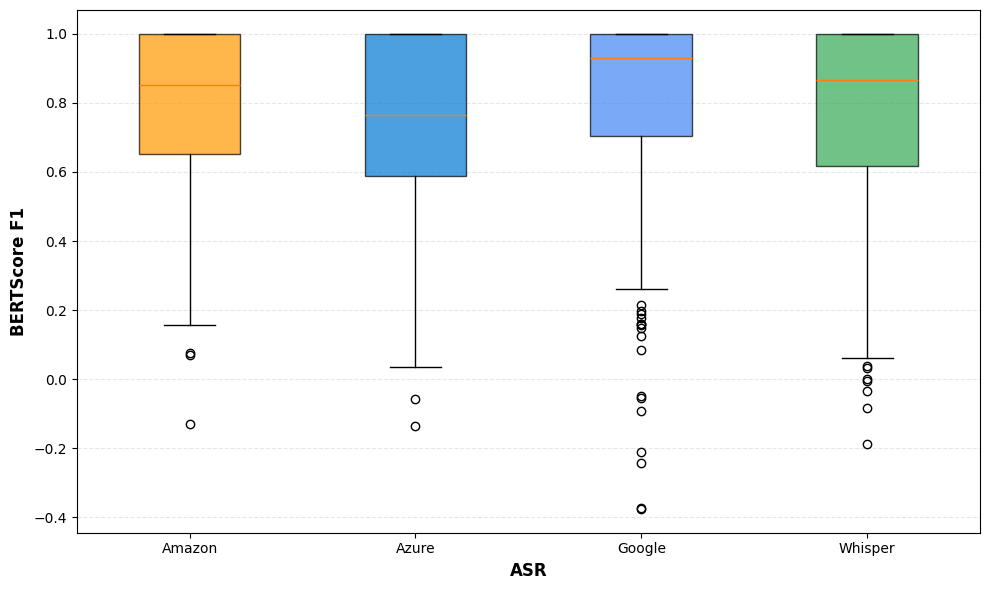


Estadísticas Descriptivas de BERTScore F1 por ASR (0dB)


ASR,Media,Mediana,Mínimo,Máximo,Desv. Est.,Q1,Q3,IQR,Muestras
Amazon,0.7956,0.8510,-0.1296,1.0000,0.2191,0.6531,1.0000,0.3469,450
Azure,0.7425,0.7634,-0.1363,1.0000,0.2433,0.5871,1.0000,0.4129,450
Google,0.8230,0.9303,-0.3755,1.0000,0.2431,0.7039,1.0000,0.2961,450
Whisper,0.7778,0.8669,-0.1875,1.0000,0.2555,0.6173,1.0000,0.3827,450


In [6]:
# Filtrar datos para 0dB
df_0db = analyzer.df[analyzer.df['snr'] == '0dB']

# Visualizar boxplot para 0dB
BERTScoreVisualizer.plot_bertscore_boxplot(df_0db, title="Distribución de BERTScore F1 por ASR (0dB)")

# Mostrar estadísticas detalladas para 0dB
BERTScoreVisualizer.display_detailed_statistics(df_0db, title="Estadísticas Descriptivas de BERTScore F1 por ASR (0dB)")

Correlación de Spearman entre WER y BERTScore F1 por ASR:


ASR,Spearman Rho,p-value,Significativo,Muestras
Amazon,-0.8995,0.0000e+00,True,1500
Azure,-0.8967,0.0000e+00,True,1500
Google,-0.8101,0.0000e+00,True,1500
Whisper,-0.8637,0.0000e+00,True,1500


Relación entre WER y BERTScore F1 por ASR


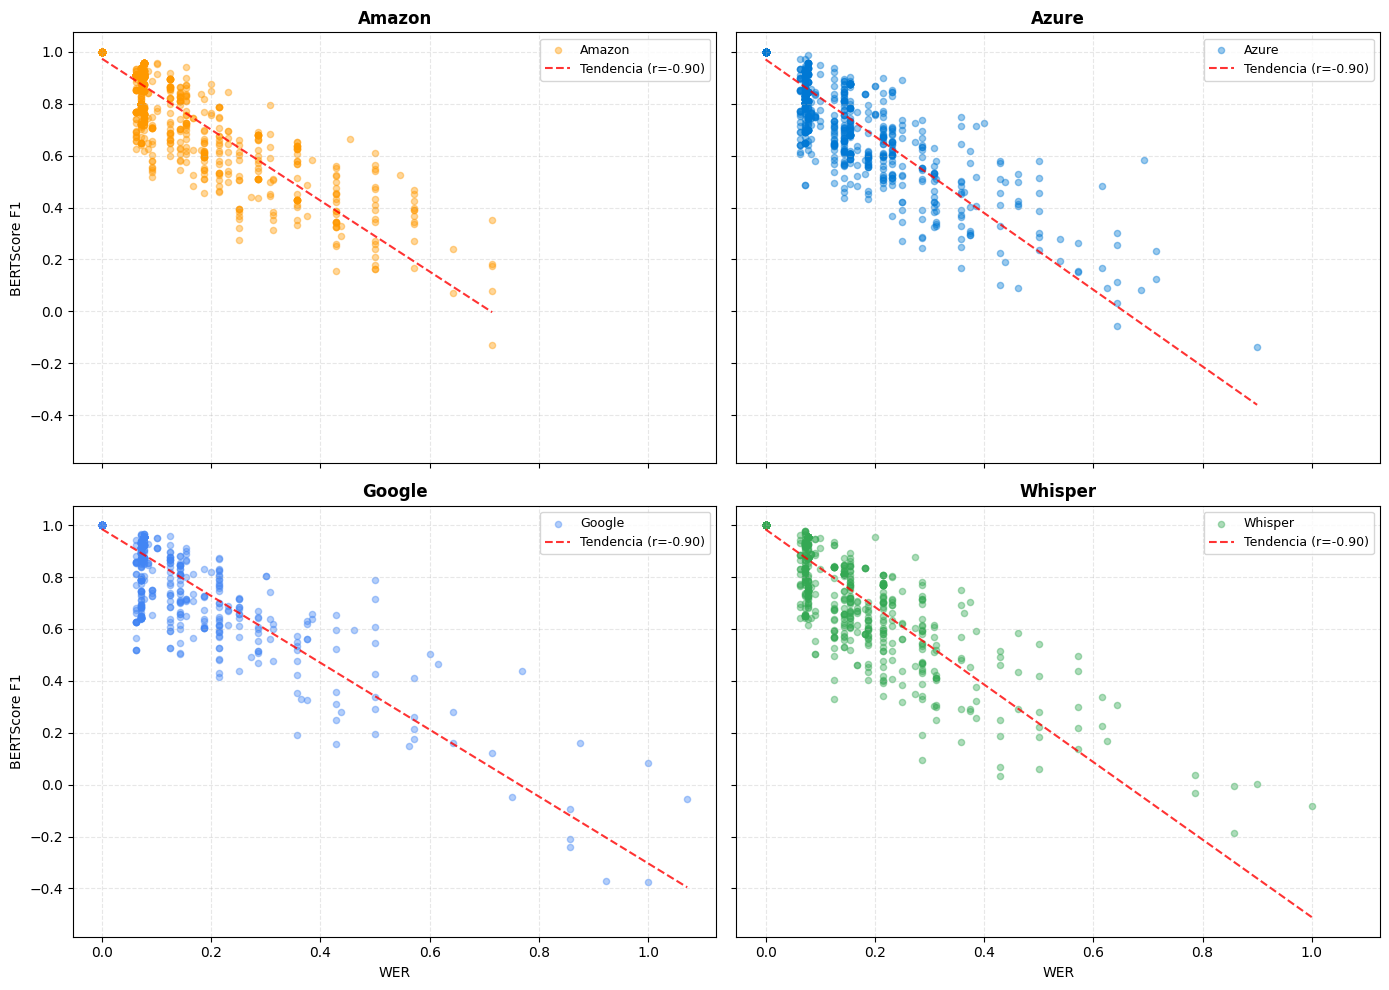

In [7]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
from tools.wer_utils import calculate_wer_from_dataframe

# 1. Calcular WER por fila si no existe dataset_wer.csv o usar dataset_normalized.csv
# Como dataset_wer.csv existe, lo cargamos directamente
try:
    df_wer = pd.read_csv('dataset_wer.csv')
except FileNotFoundError:
    # Fallback: calcularlo al vuelo si no existiera
    print("Calculando WER...")
    _, df_wer = calculate_wer_from_dataframe(pd.read_csv('dataset_normalized.csv'), 'ground_truth.json')

# 2. Asegurar que tenemos BERTScore (ya cargado en analyzer.df o df_bert)
df_bert = analyzer.df.copy()

# 3. Unir DataFrames por las claves
merge_keys = ['person', 'audio', 'noise', 'snr', 'provider']
# Seleccionamos solo las columnas necesarias de cada uno para evitar duplicados
df_merged = pd.merge(
    df_wer[merge_keys + ['wer']], 
    df_bert[merge_keys + ['bertscore_f1']], 
    on=merge_keys, 
    how='inner'
)

print("Correlación de Spearman entre WER y BERTScore F1 por ASR:")
results_corr = []

for provider in sorted(df_merged['provider'].unique()):
    subset = df_merged[df_merged['provider'] == provider]
    
    # Calcular correlación de Spearman
    # Se usa Spearman porque la relación no es necesariamente lineal y WER puede tener outliers
    rho, p_val = stats.spearmanr(subset['wer'], subset['bertscore_f1'])
    
    results_corr.append({
        'ASR': provider.capitalize(),
        'Spearman Rho': rho,
        'p-value': p_val,
        'Significativo': p_val < 0.05,
        'Muestras': len(subset)
    })

df_corr = pd.DataFrame(results_corr)
display(df_corr.style.format({
    'Spearman Rho': '{:.4f}',
    'p-value': '{:.4e}'
}).hide(axis='index'))

# 4. Visualización: Gráficos de dispersión (Scatter plots)
print("Relación entre WER y BERTScore F1 por ASR")
providers = sorted(df_merged['provider'].unique())
colors = {'google': '#4285F4', 'azure': '#0078D4', 'amazon': '#FF9900', 'whisper': '#34A853'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, provider in enumerate(providers):
    ax = axes[i]
    subset = df_merged[df_merged['provider'] == provider]
    
    # Scatter plot
    ax.scatter(subset['wer'], subset['bertscore_f1'], 
               alpha=0.4, s=20, label=f'{provider.capitalize()}', color=colors.get(provider, 'gray'))
    
    # Línea de tendencia (regresión lineal simple para visualizar)
    # Nota: Spearman es no lineal, pero la línea ayuda a ver la dirección
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['wer'], subset['bertscore_f1'])
    x_vals = np.array([subset['wer'].min(), subset['wer'].max()])
    y_vals = slope * x_vals + intercept
    ax.plot(x_vals, y_vals, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Tendencia (r={r_value:.2f})')

    ax.set_title(f"{provider.capitalize()}", fontsize=12, fontweight='bold')
    ax.set_xlabel("WER" if i >= 2 else "")
    ax.set_ylabel("BERTScore F1" if i % 2 == 0 else "")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()